In [1]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [2]:
from tensorflow.keras.models import Sequential

model = Sequential()

print(model)

<Sequential name=sequential, built=False>


In [3]:
from tensorflow.keras.layers import Dense

model.add(Dense(32))

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import joblib

load dataset

In [5]:
df = pd.read_csv("../dataset/processed_taxi.csv")

df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,2,0,3.0,1,0,3.56,0.80,0.32,53.82,36.2624
1,36.87,1,1,1.0,0,0,2.70,1.21,0.15,37.27,52.9032
2,8.64,0,1,2.0,2,0,2.55,1.71,0.48,89.33,60.2028
3,41.79,3,1,3.0,0,0,4.60,1.77,0.11,86.95,88.1328
4,9.91,1,0,2.0,0,0,2.32,1.26,0.34,41.72,28.9914


In [6]:
X = df.drop("Trip_Price", axis=1)

y = df["Trip_Price"]


print("X :", X.shape)
print("y :", y.shape)

X : (562, 10)
y : (562,)


Train test split

In [7]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

Training : (449, 10)
Testing  : (113, 10)


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

simpan scaler

In [9]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [10]:
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1)
])

d:\3D\Data Mining\SmartTripCostPredictor (projek uas)\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [12]:


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [13]:


history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 4843.9165 - mae: 56.4428 - val_loss: 5781.7529 - val_mae: 59.5362
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4788.6270 - mae: 56.0055 - val_loss: 5725.2007 - val_mae: 59.1060
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4733.4702 - mae: 55.5696 - val_loss: 5666.8423 - val_mae: 58.6621
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4676.5220 - mae: 55.0970 - val_loss: 5601.3242 - val_mae: 58.1658
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4610.9067 - mae: 54.5687 - val_loss: 5527.1665 - val_mae: 57.6010
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4536.9907 - mae: 53.9498 - val_loss: 5438.5361 - val_mae: 56.9255
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4444.0391 - mae: 53.2147 - val_loss: 5334.9419 - val_mae: 56.1287
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4339.9165 - mae: 52.3218 - val_loss: 5204.9067 - val_mae: 55.1

prediksi data testing

In [14]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


menghitung MAE RSME dan R2

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

MAE  : 7.046654739029988
RMSE : 11.923798690807596
R²   : 0.9433736226652052


membandingkan nilai aslli dan prediksi

In [16]:
hasil = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.flatten()
})

hasil.head(10)

,Actual,Predicted
0,36.0978,32.474430
1,87.7201,95.755417
2,43.8544,35.149544
3,52.5934,38.143074
4,43.6034,48.305603
5,19.3694,27.966110
6,72.9690,82.660576
7,36.0271,32.873714
8,51.2721,54.657166
9,54.6715,75.521660


visualisasi hasil prediksi

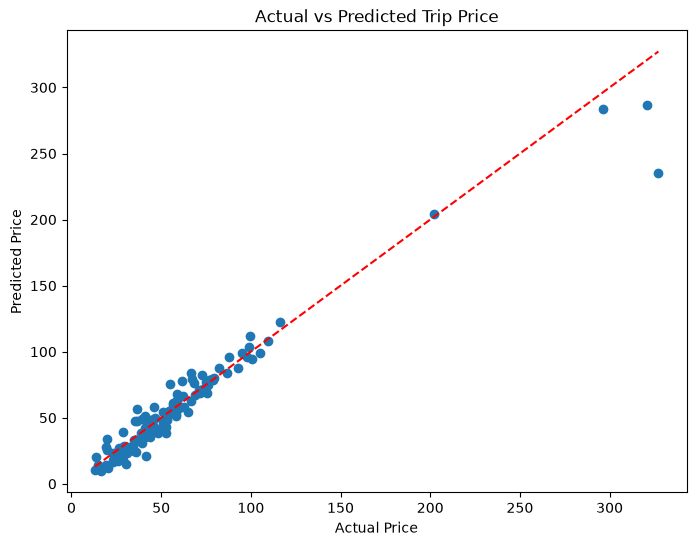

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Trip Price")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

simpan model

In [18]:
model.save("../models/ann_model.keras")

model ann 2

In [19]:
model2 = Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
])

In [20]:
model2.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [21]:
history2 = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 4751.3950 - mae: 55.7293 - val_loss: 5658.2544 - val_mae: 58.5660
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4629.3569 - mae: 54.6832 - val_loss: 5493.0967 - val_mae: 57.2514
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4442.4712 - mae: 53.0655 - val_loss: 5234.5332 - val_mae: 55.1444
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4155.9883 - mae: 50.4374 - val_loss: 4831.3638 - val_mae: 51.7535
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3716.9255 - mae: 46.3562 - val_loss: 4247.1528 - val_mae: 46.6381
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3120.1636 - mae: 40.5137 - val_loss: 3488.8660 - val_mae: 39.4931
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2379.7141 - mae: 33.0094 - val_loss: 2645.3801 - val_mae: 31.0743
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1670.8608 - mae: 24.7199 - val_loss: 1862.4139 - val_mae: 23.8854

In [22]:
y_pred2 = model2.predict(X_test)

mae2 = mean_absolute_error(y_test, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
r22 = r2_score(y_test, y_pred2)

print("MAE :", mae2)
print("RMSE :", rmse2)
print("R² :", r22)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
MAE : 6.964209432565644
RMSE : 10.814000816909486
R² : 0.9534239875486707


model ann 3

In [24]:
model3 = Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
])

In [25]:
model3.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [26]:
history3 = model3.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 4825.3730 - mae: 56.2965 - val_loss: 5739.9214 - val_mae: 59.1809
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4687.8267 - mae: 55.1571 - val_loss: 5521.1074 - val_mae: 57.4909
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4404.6167 - mae: 52.7884 - val_loss: 5051.4258 - val_mae: 53.7593
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3780.0596 - mae: 47.5026 - val_loss: 4077.3889 - val_mae: 45.4300
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2691.5901 - mae: 36.8282 - val_loss: 2501.5496 - val_mae: 30.0599
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1380.6764 - mae: 22.7827 - val_loss: 1213.2917 - val_mae: 18.8044
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 764.3911 - mae: 18.4102 - val_loss: 906.4246 - val_mae: 18.1644
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 541.4979 - mae: 16.3638 - val_loss: 667.1609 - val_mae: 13.9897
Ep

In [27]:
y_pred3 = model3.predict(X_test)

mae3 = mean_absolute_error(y_test, y_pred3)
rmse3 = np.sqrt(mean_squared_error(y_test, y_pred3))
r23 = r2_score(y_test, y_pred3)

print("MAE :", mae3)
print("RMSE :", rmse3)
print("R² :", r23)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000021FB707C040> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
MAE : 6.9511572098461984
RMSE : 11.029533774674126
R² : 0.9515488803047951


perbandingan ketiga hasil model ann

In [28]:
hasil_model = pd.DataFrame({
    "Model": ["ANN 1", "ANN 2", "ANN 3"],
    "Arsitektur": ["32-16", "64-32-16", "128-64-32-16"],
    "MAE": [mae, mae2, mae3],
    "RMSE": [rmse, rmse2, rmse3],
    "R2": [r2, r22, r23]
})

hasil_model

,Model,Arsitektur,MAE,RMSE,R2
0,ANN 1,32-16,7.046655,11.923799,0.943374
1,ANN 2,64-32-16,6.964209,10.814001,0.953424
2,ANN 3,128-64-32-16,6.951157,11.029534,0.951549


simpan model terbaik

In [29]:
# Simpan model terbaik (ANN 2)
model2.save("../models/ann_model.keras")

print("Model ANN terbaik berhasil disimpan!")

Model ANN terbaik berhasil disimpan!
